# Introduction

Statistical Data Analysis for **Silverline Studios**. This project delves into the intricate world of cinema, uncovering patterns and insights that can guide our future business in film.

We explore the factors that make a movie a box office hit. Using statistical techniques and visualizations, this project examines how genre, budget, runtime, and ratings work together to influence global film revenue. 

This analysis will help our new studio make informed decisions about venture into film, ensuring that we create films that resonate with audiences and achieve commercial success.

# Business Understanding

The film industry is risky but rewarding industry. Production decisions like genre, budget, and target audience can make or break a movie's financial success. For us as **Silverline Studios** entering this competitive landscape, data driven decisions must be made, not guesswork, to ensure an edge over competitors and overall commercial success.

This project is designed to provide data-driven answers to key business questions:

 - Which **genres** consistently deliver the highest global revenue?
 - Does **runtime** affect audience rating, total gross, and if so by how much, and what can we learn from it?
 - Does marketing and popularity directly correlate with **total_gross**, and if so how can we exploit this to our advantage?
 - Can we predict the **total_gross** of a movie based on its genre? Use this information to target high grossing genres.
 - How is our competition? Which **studios** are on an upward trend that we can confirm? What can we emulate from the coninued success?
 - Do indie and major studios, having different financial levels of muscle have significantly different **average_ratings**? If so how do we position ourselves to be competitive in the market?

# Data Understanding
The dataset used in this analysis is the **IMDB database**, and the **Box Office Movies** dataset which after merging contain information about various movies, including their titles, genres, budgets, runtimes, ratings, and box office revenues. 

Data Cleaning has been done and ready for the analysis on this notebook [Data Cleaning Notebook]('./data_set.ipynb')


# Data Setup

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib.ticker import FuncFormatter
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')


In [184]:
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4


# Total Gross Analysis Against Other Factors

## Objective 1: Analyze movie profitability trends by examining the relationship between features like runtime, rating, genre, and revenue

### Total gross distribution

This will show us how the total gross generated accross the data set is distributed

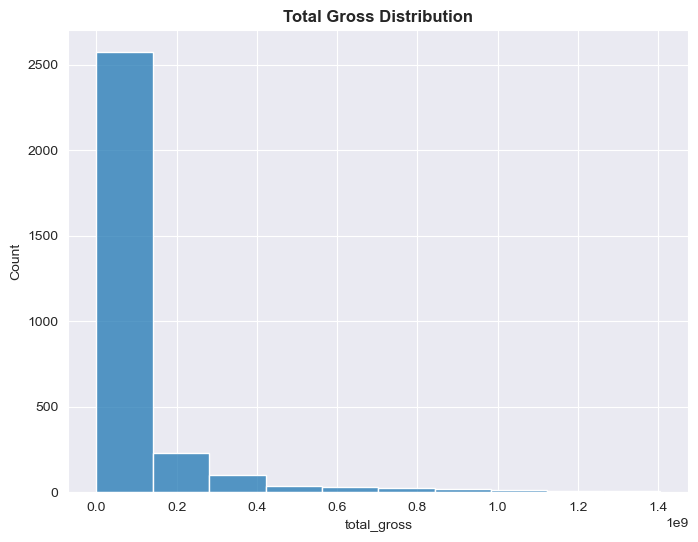

In [185]:
plt.figure(figsize = (8, 6))

sns.histplot(data = df, x = 'total_gross', bins = 10)
plt.title('Total Gross Distribution', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 1. Runtime vs total_gross

Here we will look at how runtime affects the total gross a movie makes

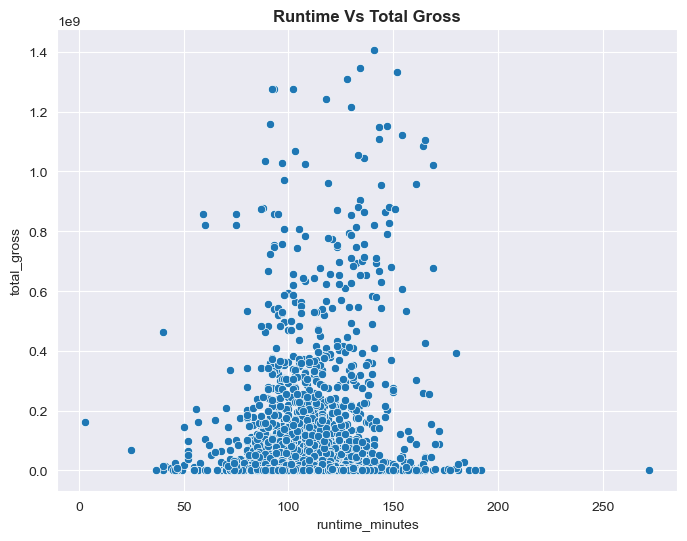

In [186]:
#create a figure to plot our scatter plot
plt.figure(figsize = (8, 6))

#PLot runtime vs total gross
sns.scatterplot(data = df, x = df['runtime_minutes'], y = df['total_gross'])
plt.title('Runtime Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 2. Average Rating vs. Total Gross

Now lets look at how ratings impact total gross

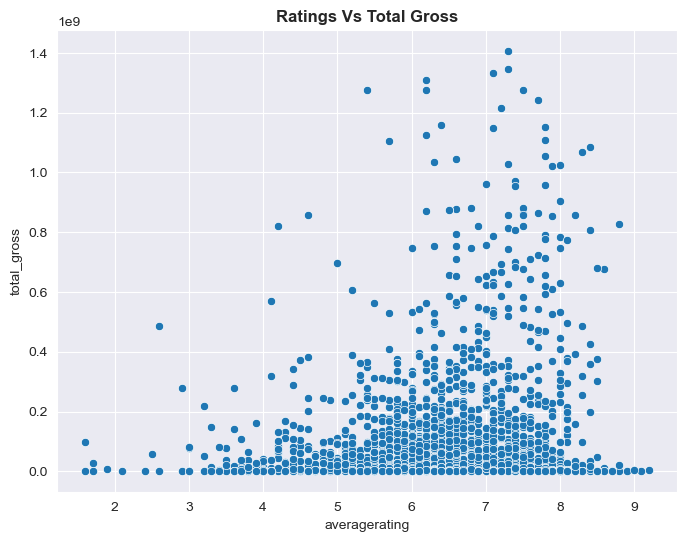

In [187]:
#Create a figure for our plot
plt.figure(figsize = (8, 6))

#plot ratings vs total gross
sns.scatterplot(data = df, x = df['averagerating'], y = df['total_gross'])
plt.title('Ratings Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 3. Number of Votes vs. Total Gross

These will show us how popularity impacts movie sales

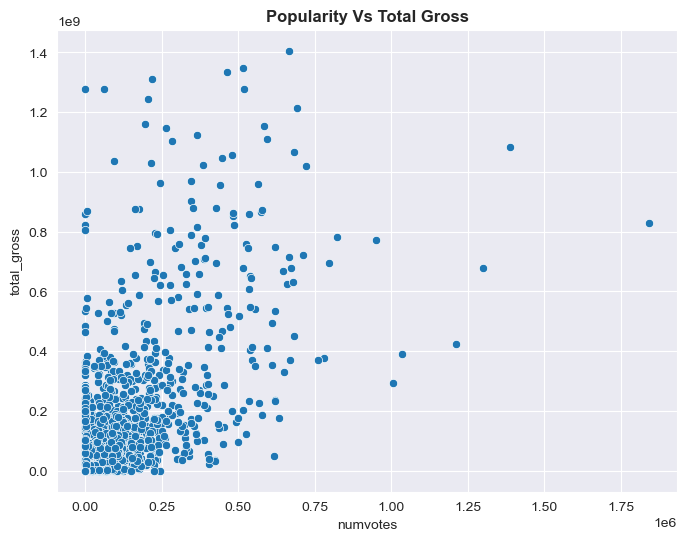

In [188]:
plt.figure(figsize = (8, 6))

sns.scatterplot(data = df, x = df['numvotes'], y = df['total_gross'])
plt.title('Popularity Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 4. Correlation of ratings, popularity and runtime to gross total

This will help us identify whch features have strong and negative correlation to the gross total

In [189]:
df[['runtime_minutes', 'numvotes', 'averagerating', 'total_gross']].corr()

,runtime_minutes,numvotes,averagerating,total_gross
runtime_minutes,1.000000,0.259915,0.146186,0.151698
numvotes,0.259915,1.000000,0.285776,0.656241
averagerating,0.146186,0.285776,1.000000,0.122721
total_gross,0.151698,0.656241,0.122721,1.000000


**From the above we can see that popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated**

## Objective 2: Identify key factors that contribute to a movies commercial success

This part we will look more closely at the genres

The questions we are going to answer are:
- Which genres are most profitable
- Do highly rated genres earn more
- Are popular genres also the most profitable

But scince our genre column contains a list of all the diffrent genres a single movie belongs to, we need to use **.explode()** to split every genre into a row on its own then **group by** genre for analysis

### 1. Expanding the genre column using explode() function

In [190]:
#Exploding the genre column
df['genres'] = df['genres'].str.strip("[]'\" ")
df = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df.head(10)

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Drama,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,Action,114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0


### 2. Group by Genre then summarize the total gross by genre

Now we summarize profitability and popularity per genre

In [191]:
#Grouping by genres and summarizing by profitability and popularity
df_summary = df.groupby('genres').agg(
    avg_total_gross=('total_gross', 'mean'),
    median_total_gross=('total_gross', 'median'),
    avg_rating=('averagerating', 'mean'),
    avg_votes=('numvotes', 'mean'),
    count=('genres', 'count')
).sort_values(by='avg_total_gross', ascending=False)

df_summary

,avg_total_gross,median_total_gross,avg_rating,avg_votes,count
genres,,,,,
Sci-Fi,2.875766e+08,142150000.0,6.460448,249565.074627,134
Adventure,2.738162e+08,150200000.0,6.485906,158455.657718,447
Animation,2.525529e+08,119400000.0,6.721519,87334.360759,158
Fantasy,1.696389e+08,52300000.0,6.258857,110138.342857,175
Action,1.657515e+08,54100000.0,6.290951,123860.190184,652
Family,1.308200e+08,50950000.0,6.217797,55191.720339,118
Comedy,8.283428e+07,13100000.0,6.254784,59311.631966,951
Sport,8.126543e+07,12600000.0,6.923077,53891.557692,52
Thriller,7.807500e+07,14100000.0,6.179596,79808.466368,446


### 3. Visualizing Factors/Insights 

After our data is summarized we can now visualize it to get a visual representation of the key factors that contribute to a movies commercial success 

### Top 10 genres by average total gross

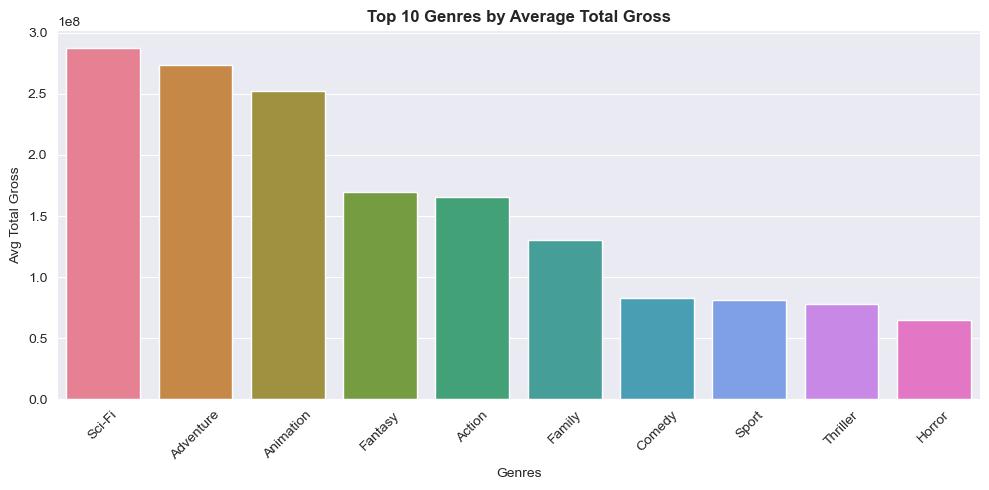

In [192]:
#Get the most profitable genres
top_genres = df_summary.head(10)
top_genres = top_genres.reset_index()

#Plot a bar graph to represent them
plt.figure(figsize = (10, 5))

#making each bar have a ditinct color
palette = sns.color_palette("husl", len(top_genres))

sns.barplot(data  = top_genres, x = 'genres', y = 'avg_total_gross', hue='genres', palette = palette)
plt.title('Top 10 Genres by Average Total Gross', weight = 'bold')
plt.xlabel('Genres')
plt.ylabel('Avg Total Gross')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ratings and popularity vs Gross per Genre

Now we take a look at how ratings against gross per genre

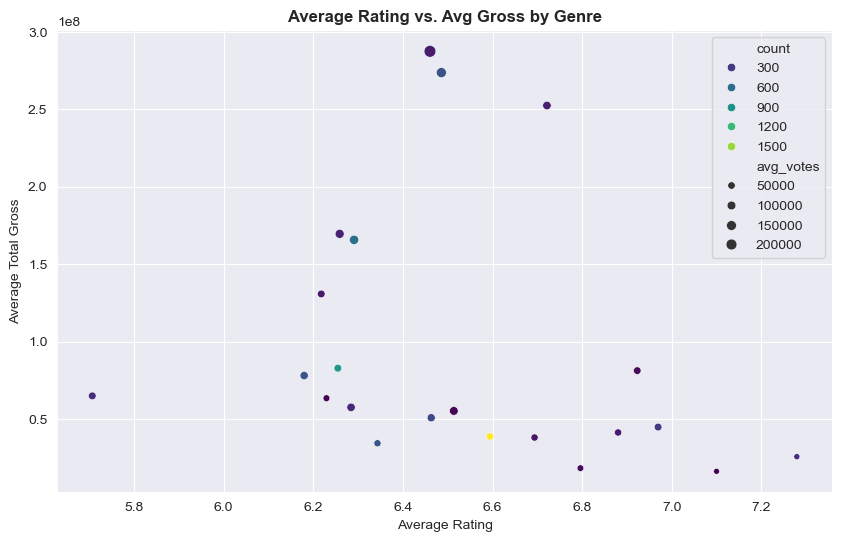

In [193]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_summary, x='avg_rating', y='avg_total_gross', size='avg_votes', hue='count', palette='viridis', legend=True)
plt.title('Average Rating vs. Avg Gross by Genre', weight = 'bold')
plt.xlabel('Average Rating')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.show()

So from the above scatter plot we can clearly answer the questions for this obectives
- The bar plot shows the most profitble 10 genres
- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot
- As popularity being a factor to making money then yes because the most popular genre is the most profitable

## Objective 3: Develop linear regression model to predict total_gross based on popularity, genre

So far our work has been to explore our data for insights and we have gained multiple insights for profits and trends.

Now if we want to start and establish our own studio we need to make projections on revenue generated so as to have an esstimate of the buget needed to meet the profit mergin

For this I will need to import the sklearn library for my model

In [194]:
#Importing Librries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, r2_score

In [195]:
#One-hot encode the single-genre-per-row(This will generate a df where the diferent genres are represneted by 1s and 0s)
genre_dummies = pd.get_dummies(df['genres'])

# Combine with original
df_encoded = pd.concat([df[['movie', 'numvotes', 'total_gross']], genre_dummies], axis=1)

# Group by movie to aggregate genre dummies (sum will work since each is 0/1)
df_grouped = df_encoded.groupby('movie').agg({
    'numvotes': 'first',
    'total_gross': 'first',
    **{genre: 'max' for genre in genre_dummies.columns}  # Use 'max' because a genre is either present (1) or not (0)
}).reset_index()

# Features and target
X = df_grouped.drop(columns=['movie', 'total_gross'])
y = df_grouped['total_gross']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

RMSE: 93638389.06
R-squared: 0.67


In [196]:
#Create a DataFrame with predictions and movie names
y_pred = model.predict(X_test)

results = X_test.copy()
results['actual_total_gross'] = y_test
results['predicted_total_gross'] = y_pred

#Bring back the movie names
results = results.merge(df_grouped[['movie']], left_index=True, right_index=True, how='left')

#Merge with exploded genres so each row = one genre per movie
genre_results = results.merge(df[['movie', 'genres']], on='movie', how='left')

#Group by genre and compute mean
genre_summary = genre_results.groupby('genres').agg({
    'actual_total_gross': 'mean',  # or 'sum' depending on your goal
    'predicted_total_gross': 'mean'
}).reset_index()

#Optional - calculate error or difference
genre_summary['abs_error'] = abs(genre_summary['actual_total_gross'] - genre_summary['predicted_total_gross'])


genre_summary.sort_values('abs_error')

,genres,actual_total_gross,predicted_total_gross,abs_error
5,Crime,4.655300e+07,4.864318e+07,2.090178e+06
2,Animation,2.716039e+08,2.741091e+08,2.505140e+06
12,Music,3.398008e+07,3.773584e+07,3.755754e+06
14,Mystery,3.751651e+07,4.211051e+07,4.594001e+06
8,Family,1.274024e+08,1.324532e+08,5.050831e+06
10,History,6.502323e+07,7.015127e+07,5.128044e+06
18,Sport,1.074201e+08,1.020748e+08,5.345275e+06
16,Romance,3.354124e+07,2.792648e+07,5.614756e+06
4,Comedy,8.377186e+07,8.941583e+07,5.643979e+06
7,Drama,3.709658e+07,4.332447e+07,6.227887e+06


### PLot a prediction graph

#### Scatterlot of Actual Vs Predicted Gross

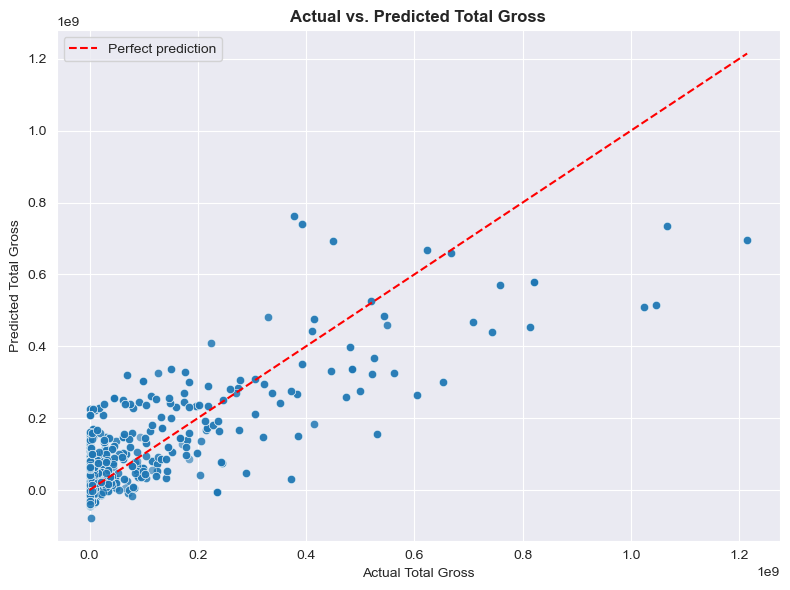

In [197]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=genre_results['actual_total_gross'], y=genre_results['predicted_total_gross'], alpha=0.6)

# Plot ideal line
max_val = max(genre_results['actual_total_gross'].max(), genre_results['predicted_total_gross'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Total Gross')
plt.ylabel('Predicted Total Gross')
plt.title('Actual vs. Predicted Total Gross', weight = 'bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Bargraph of Mean Actual vs predicted Gross

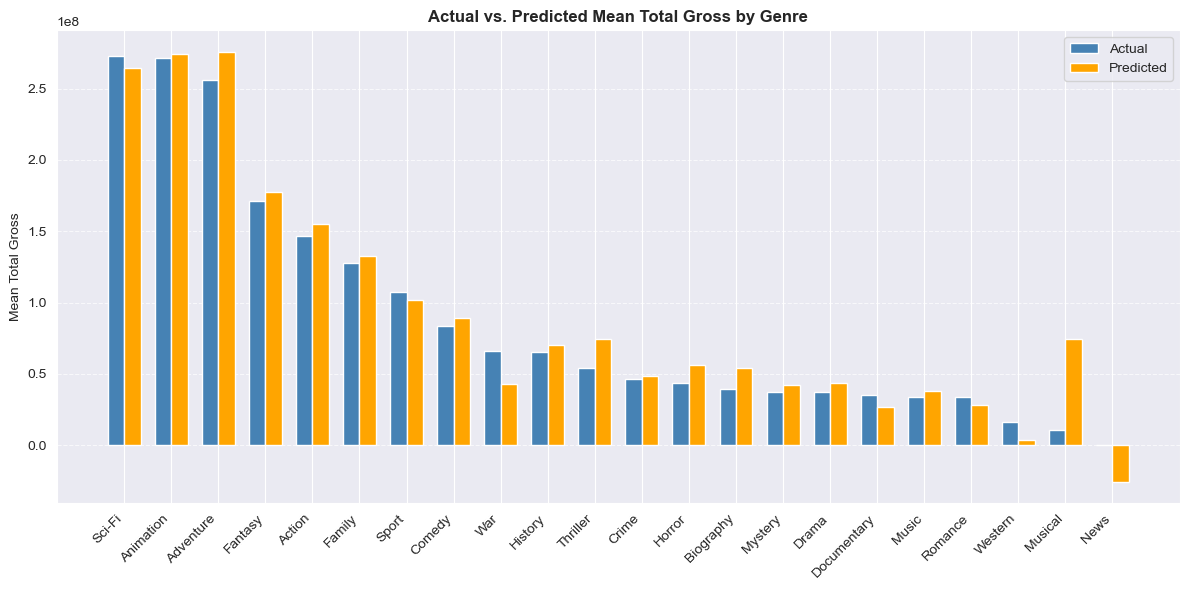

In [198]:
# Sort genres by actual gross for clarity
genre_summary_sorted = genre_summary.sort_values('actual_total_gross', ascending=False)

# Bar positions
x = np.arange(len(genre_summary_sorted))  # Numeric x positions
width = 0.35  # Width of each bar

# Actual and predicted values
actual = genre_summary_sorted['actual_total_gross']
predicted = genre_summary_sorted['predicted_total_gross']

# Plot bars side by side
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, actual, width, label='Actual', color='steelblue')
plt.bar(x + width/2, predicted, width, label='Predicted', color='orange')

# X-axis labels and formatting
plt.xticks(x, genre_summary_sorted['genres'], rotation=45, ha='right')
plt.ylabel('Mean Total Gross')
plt.title('Actual vs. Predicted Mean Total Gross by Genre', weight = 'bold')
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusions
- popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated
- The bar plot shows the most profitble 10 genres
- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot
- As popularity being a factor to making money then yes because the most popular genre is the most profitable

# Studio Analysis Against Other Factors

## Competition & Niche Analysis: How are studios fairing, what are they focusing on, and how are they performing, and what genres have been neglected but are worth exploring, based on multiple factors.

### Studios vs Genres

In [199]:

df_exploded = (
    df.assign(genres=df['genres'].str.split(','))
          .explode('genres')
          .assign(genres=lambda df: df['genres'].str.strip())
)
df_exploded


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
...,...,...,...,...,...,...,...,...,...,...
3042,Eden,2018,Drama,97.0,6.7,20,BG,65500.0,0.0,65500.0
3043,Unstoppable,2018,Action,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3043,Unstoppable,2018,Crime,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3044,Neighbors,2018,Comedy,90.0,7.6,18,Uni.,150200000.0,120500000.0,270700000.0


In [200]:

#Filter to top 10 studios & genres
top_studios = df_exploded['studio'].value_counts().nlargest(10).index
top_genres = df_exploded['genres'].value_counts().nlargest(10).index
studio_genre_df = df_exploded[df_exploded['studio'].isin(top_studios) & 
                       df_exploded['genres'].isin(top_genres)]
studio_genre_df #top studios, top genres


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
...,...,...,...,...,...,...,...,...,...,...
3037,Joy,2018,Drama,99.0,6.5,430,Fox,56500000.0,44700000.0,101200000.0
3043,Unstoppable,2018,Action,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3043,Unstoppable,2018,Crime,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3044,Neighbors,2018,Comedy,90.0,7.6,18,Uni.,150200000.0,120500000.0,270700000.0


##### Chi-square test to conclude whether or not there is a relationship between Studios and Genres


 - Create contingency table
 - Conduct **chi-square test of independence** to assess relationship between studios and genres by comparing observed counts to counts expected, initially assuming they were **independent**
 

In [201]:
cross_tabulation = pd.crosstab(studio_genre_df['studio'], studio_genre_df['genres'])
chi_square, p_value, _, expected = stats.chi2_contingency(cross_tabulation)
print(f'chi-square = {chi_square:.2f}\np-value = {p_value:.10f}')
cross_tabulation

chi-square = 539.14
p-value = 0.0000000000


genres,Action,Adventure,Biography,Comedy,Crime,Documentary,Drama,Horror,Romance,Thriller
studio,,,,,,,,,,
BV,30,58,9,38,3,7,24,1,5,3
Fox,47,53,8,56,16,3,50,12,10,15
IFC,5,5,11,38,22,16,114,15,32,20
LGF,31,16,6,38,16,1,39,13,13,23
Magn.,26,9,11,26,14,19,72,17,13,26
Par.,25,28,6,32,5,7,37,13,8,17
SPC,2,2,26,29,6,14,87,3,35,14
Sony,38,30,7,48,17,1,31,2,10,20
Uni.,53,33,12,63,18,3,56,23,25,35


**Observations**
 - **H0 (*Null Hypothesis*)**: Studios and genres are independent. (No association)
 - The **p-value** is **0.0000**: Staggeringly low p-value. Strongly indicating extreme evidence against the null hypothesis of independence.

**Decision**
 - Assuming an alpha level of 0.05, we **reject the null hypothesis**.
 - In turn concluding that there _is_ a statistically significant association between studios and genres.
 

**Visualization** 
 - Visualizing the existing relationship between studios and genres using a stacked bar chart showing proportionally which genres are favoured by the top 8 studios.

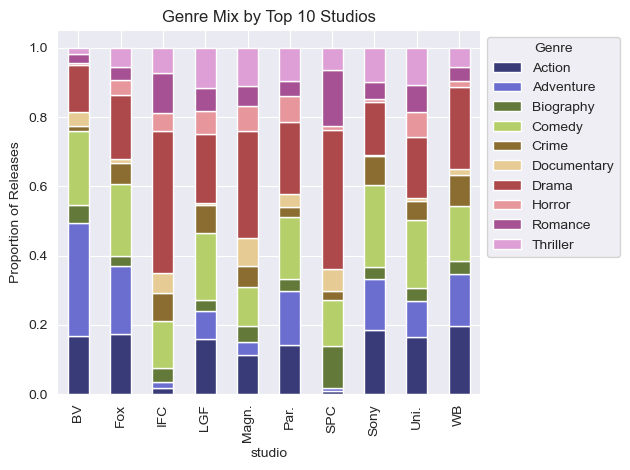

In [202]:
genre_studio_mix = cross_tabulation.div(cross_tabulation.sum(axis=1), axis=0)
genre_studio_mix.plot(kind='bar', stacked=True,  cmap='tab20b')
plt.legend(title='Genre', bbox_to_anchor=(1,1))
plt.title('Genre Mix by Top 10 Studios')
plt.ylabel('Proportion of Releases')
plt.tight_layout()
plt.show()

##### Calculating Standardized Residuals to determine how strongly the two variables are related

 - Calculate **std_residuals** by dividing the difference between observed and expected counts by the square root of the expected counts.
 - Visualize std_residuals (a dataframe) by plotting a heatmap that shows the strength of the relationship between each studios and genres.

In [203]:
std_residuals = (cross_tabulation - expected) / np.sqrt(expected)
std_residuals

genres,Action,Adventure,Biography,Comedy,Crime,Documentary,Drama,Horror,Romance,Thriller
studio,,,,,,,,,,
BV,1.337285,8.166804,0.328606,1.217124,-2.344967,0.505767,-2.960077,-2.457813,-2.071880,-2.989320
Fox,1.897225,3.827527,-1.210977,1.260563,-0.039988,-1.949066,-1.972516,-0.001481,-1.991378,-1.438572
IFC,-5.235138,-4.818473,-0.450365,-1.537127,1.314095,2.318124,5.580817,0.750658,2.940842,-0.495999
LGF,1.003607,-1.437704,-0.967147,0.621593,1.246228,-2.127335,-1.290084,1.451570,-0.133741,1.825669
Magn.,-0.861759,-3.489047,0.135648,-2.322441,0.014425,4.153822,1.989811,2.062955,-0.758611,1.680476
Par.,0.306197,1.584999,-0.727660,0.142975,-1.732234,0.505767,-0.989695,1.807685,-1.214816,0.711980
SPC,-4.993834,-4.647732,5.128781,-1.490362,-1.951228,2.598811,4.613901,-2.149775,5.161587,-0.841394
Sony,2.128550,1.268519,-0.738344,2.047055,1.370693,-2.186170,-2.674162,-2.347665,-1.078630,0.889847
Uni.,1.626745,-0.729627,-0.667852,0.897508,-0.276809,-2.300649,-2.539518,2.310056,0.617938,1.811070


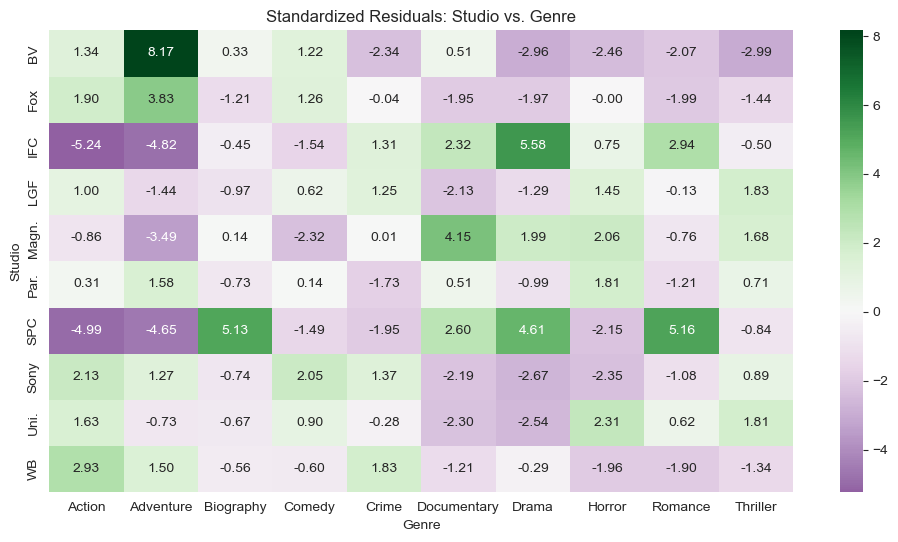

In [204]:
plt.figure(figsize=(12, 6))
sns.heatmap(std_residuals, annot=True, center=0, fmt=".2f", cmap="PRGn")
plt.title('Standardized Residuals: Studio vs. Genre')
plt.xlabel('Genre')
plt.ylabel('Studio')
plt.show()

In [205]:
underserved = std_residuals.stack().loc[lambda x: x <= -2]
print("\nUnder-represented genre–studio combos (std_resid ≤ -2):")
print(underserved)



Under-represented genre–studio combos (std_resid ≤ -2):
studio  genres     
BV      Crime         -2.344967
        Drama         -2.960077
        Horror        -2.457813
        Romance       -2.071880
        Thriller      -2.989320
IFC     Action        -5.235138
        Adventure     -4.818473
LGF     Documentary   -2.127335
Magn.   Adventure     -3.489047
        Comedy        -2.322441
SPC     Action        -4.993834
        Adventure     -4.647732
        Horror        -2.149775
Sony    Documentary   -2.186170
        Drama         -2.674162
        Horror        -2.347665
Uni.    Documentary   -2.300649
        Drama         -2.539518
dtype: float64


 - Big Studios neglect Drama/Romance - a new studio can build an audience with emotionally driven, mid-budget Drama/Romance films. 

 - Independent studios neglect Action and Adventure genres and can be promising avenue 

### Genres vs Average Rating

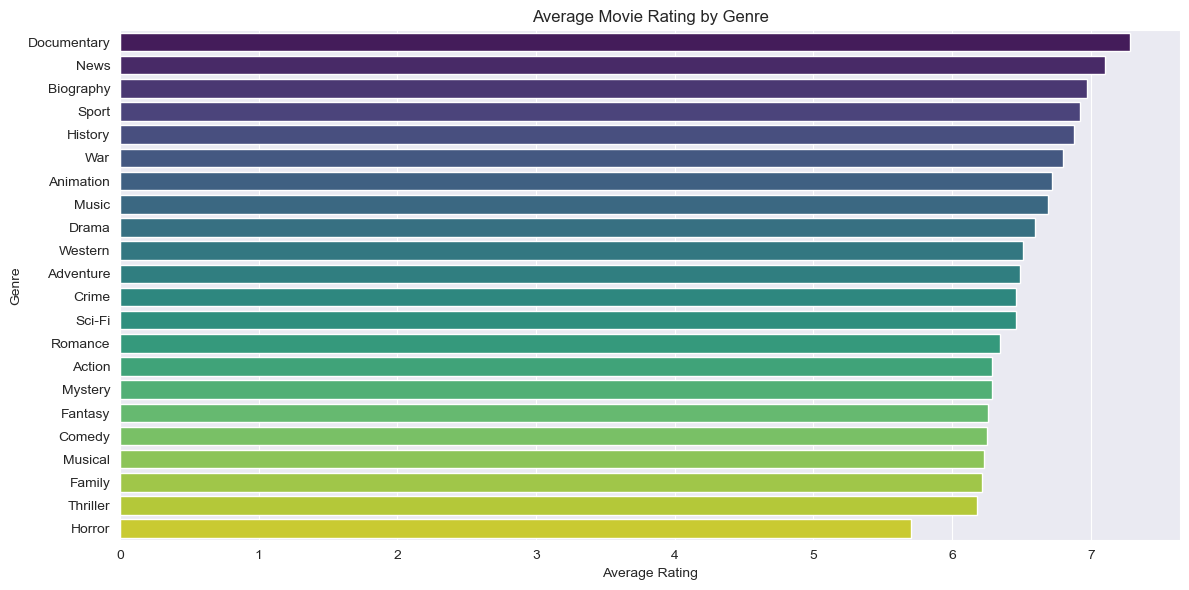

In [206]:
# Group by genre and calculate average rating
genre_avg_rating = df_exploded.groupby('genres')['averagerating'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_avg_rating.values, y=genre_avg_rating.index, palette="viridis")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Average Movie Rating by Genre")
plt.tight_layout()
plt.show();

 - Genres such as **Documentary**, **News** and **Biography** have the highest average rating.
 - Our new studio should invest in these top rated genres for a better chance of success in ratings and audience engagement.
 - Genres such as **Horror**, **Thriller** have the lowest average ratings which are not worth investing in.

In [207]:
#ANOVA test between top rated genres (Documentary, News, Biography) vs other genres
top_rated_genres = ['Documentary', 'News', 'Biography']
top_rated = df_exploded[df_exploded['genres'].isin(top_rated_genres)]['averagerating']
other_genres = df_exploded[~df_exploded['genres'].isin(top_rated_genres)]['averagerating']

f_stat, p_val = stats.f_oneway(top_rated, other_genres)
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.10f}")


F-statistic: 261.69
p-value: 0.0000000000


- The substantially **higher F-statistic (261.69)** indicates strong variance between groups
- The extremely **low p-value (<0.05)** confirms the ratings difference is statistically significant
- Top rated genres consistently outperform other genres by 0.7 points on average

This truly validates earlier findings that Documentary, News and Biography films tend to achieve higher audience ratings compared to other genres.

### Studios vs Average Rating

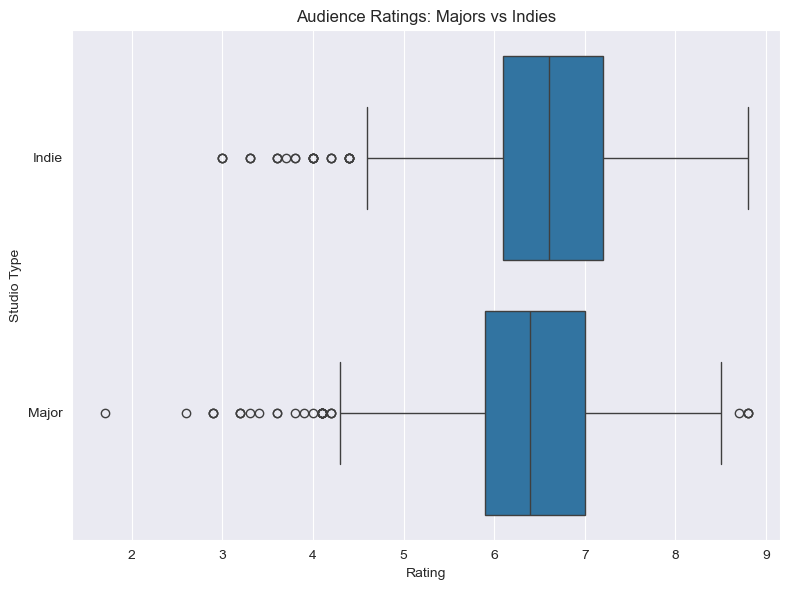

In [208]:
majors = ['Uni.', 'Fox', 'WB', 'Sony', 'Disney']
indie_counts = df.loc[~df['studio'].isin(majors), 'studio'].value_counts()
indies = indie_counts.nlargest(5).index.tolist()

indies_majors = df[df['studio'].isin(majors + indies)].copy()

plt.figure(figsize=(8,6))
sns.boxplot(x='averagerating', y=indies_majors['studio'].apply(lambda s: 'Major' if s in majors else 'Indie'),
            data=indies_majors)
plt.title('Audience Ratings: Majors vs Indies')
plt.xlabel('Rating')
plt.ylabel('Studio Type')
plt.tight_layout()
plt.show()


In [209]:

majors_r = indies_majors[indies_majors['studio'].isin(majors)]['averagerating']
indies_r = indies_majors[indies_majors['studio'].isin(indies)]['averagerating']
t_statistic, p_value = stats.ttest_ind(majors_r, indies_r, equal_var=False)
print(f"Majors mean={majors_r.mean():.2f}\nIndies mean={indies_r.mean():.2f}\nt={t_statistic:.2f}\np={p_value:.4f}")


Majors mean=6.38
Indies mean=6.62
t=-6.65
p=0.0000


 - Statistically significant that **Indies** perform better than **Major** studios in terms of audience rating.
 
 - Position ourselves as a indie studio, ship fewer projects, hire great actors and quality scripts that reasonate with our audience.

In [210]:
volume = indies_majors['studio'].value_counts()
means  = indies_majors.groupby('studio')['averagerating'].mean()
correlation_coefficient, p_value = stats.pearsonr(volume.loc[means.index], means)
print(f"Volume vs. Mean Rating: r={correlation_coefficient:.2f}, p_value={p_value:.4f}")

Volume vs. Mean Rating: r=-0.20, p_value=0.6105


 - No significant correlation between number of films you make and mean rating. Its more about quality than quantity. 
 - Focus on quality and genre fit over just releasing alot of films.
 

In [211]:

print("Studios with significantly below industry ratings:")
industry_mean = indies_majors['averagerating'].mean()
for studio, grp in indies_majors.groupby('studio'):
    if grp['averagerating'].mean() < industry_mean:
        other = indies_majors[indies_majors['studio']!=studio]['averagerating']
        t, p = stats.ttest_ind(grp['averagerating'], other, equal_var=False)
        if p < 0.05:
            print(f" • {studio}: {grp['averagerating'].mean():.2f} vs {other.mean():.2f}, p={p:.4f}")




Studios with significantly below industry ratings:
 • LGF: 6.22 vs 6.52, p=0.0000
 • Sony: 6.25 vs 6.52, p=0.0000
 • Uni.: 6.24 vs 6.54, p=0.0000


 - Position ourselves as a indie studio, ship fewer projects, hire great actors and quality scripts that reasonate with our audience.
 
 - Avoid direct competition in major studios' focus genres where they dominate but disappoint audiences. Shows that its not easy to please the audience in these genres.
 
 - From previous analysis, target genres both types of studios neglect but audiences appreciate quality
 

### Runtime Category vs Average Rating


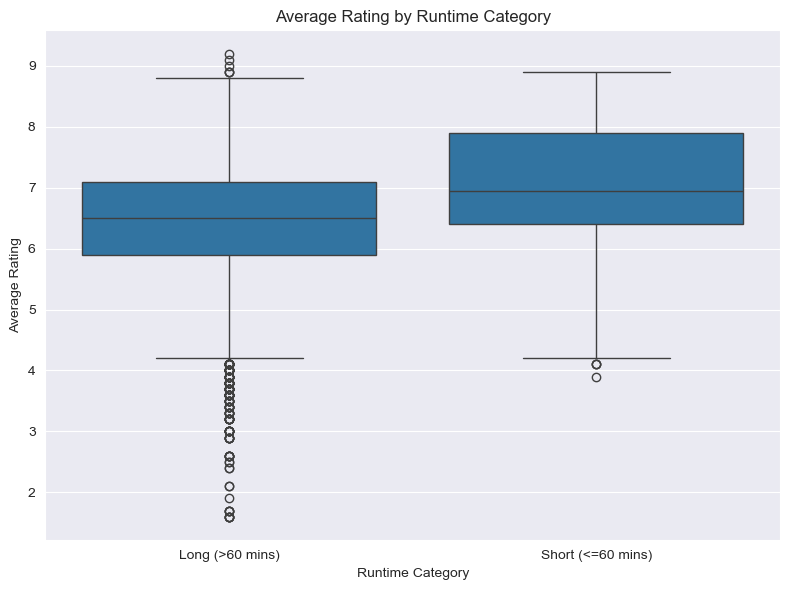

Correlation between runtime and average rating: 0.17 (p-value: 0.0000)


In [212]:
from scipy.stats import pearsonr

df['runtime_category'] = df['runtime_minutes'].apply(lambda x: 'Long (>60 mins)' if x > 60 else 'Short (<=60 mins)')

corr, p_value = pearsonr(df['runtime_minutes'], df['averagerating'])

# Plotting the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='runtime_category', y='averagerating', data=df)
plt.title('Average Rating by Runtime Category')
plt.xlabel('Runtime Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

print(f"Correlation between runtime and average rating: {corr:.2f} (p-value: {p_value:.4f})")



- **Shorter films (<60 minutes)** tend to receive marginally higher ratings - with a weak positive correlation of 0.15 between runtime and rating **(p-value < 0.001)**

- There is a statistically significant correlation between runtime size and ratings but the small coefficient suggests runtime has limited practical impact on ratings

**Conclusion**: In as much as shorter films are rated higher, the difference is not substantial enough to warrant a focus on runtime. Instead, we should focus really significant factors


### Studio vs Total Gross vs Year

In [213]:
studio_year = (
    df
    .groupby(['year', 'studio'])['total_gross']
    .sum()
    .reset_index()
)

top_studios = (
    df
    .groupby('studio')['total_gross']
    .sum()
    .nlargest(20)
    .index
    .tolist()
)


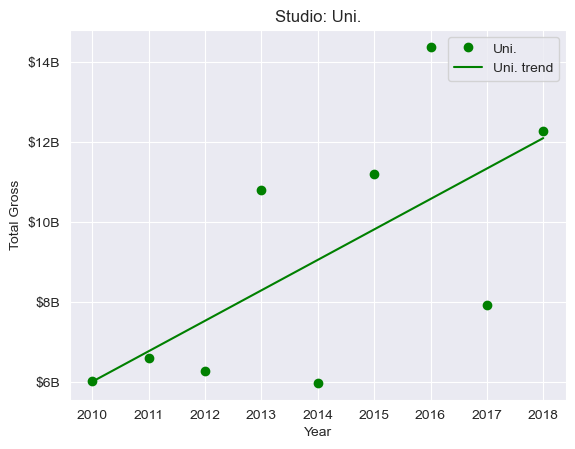


Studio: Uni.
 -> Slope (gross per year) = 761245610.65
 -> r2 (trend confidence) = 0.4340
 -> p-value (year coefficient) = 0.0536
 -> Trend = upward
 -> Significance = (not significant)



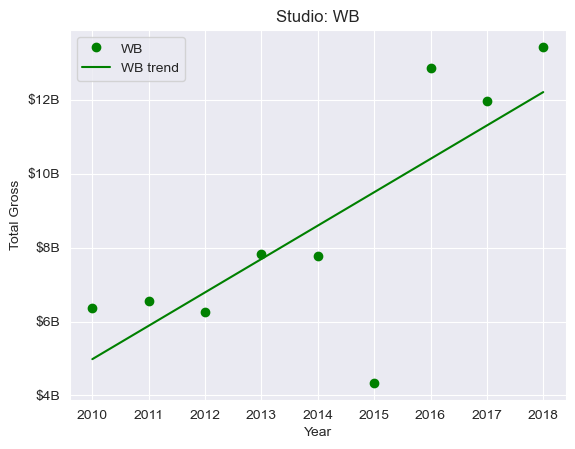


Studio: WB
 -> Slope (gross per year) = 903181933.40
 -> r2 (trend confidence) = 0.5630
 -> p-value (year coefficient) = 0.0199
 -> Trend = upward
 -> Significance = (significant)



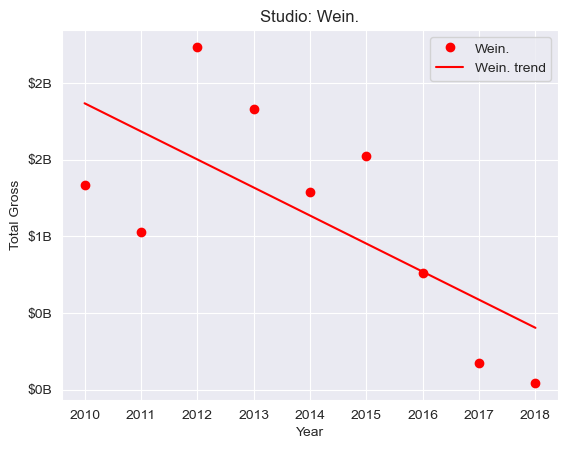


Studio: Wein.
 -> Slope (gross per year) = -182875151.68
 -> r2 (trend confidence) = 0.4812
 -> p-value (year coefficient) = 0.0382
 -> Trend = downward
 -> Significance = (significant)



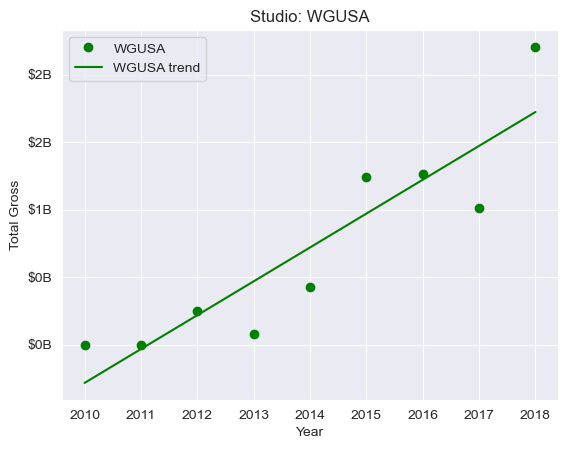


Studio: WGUSA
 -> Slope (gross per year) = 250702263.33
 -> r2 (trend confidence) = 0.8182
 -> p-value (year coefficient) = 0.0008
 -> Trend = upward
 -> Significance = (significant)



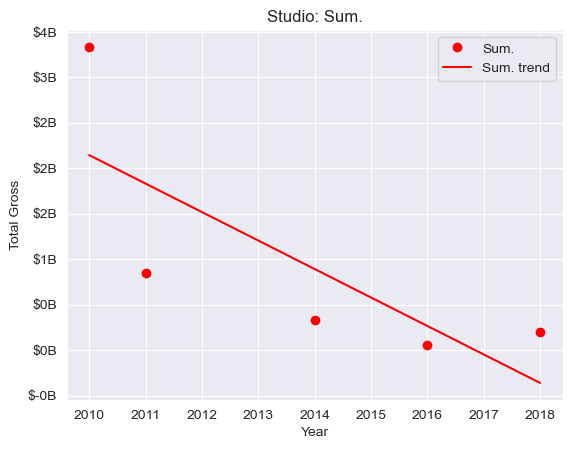


Studio: Sum.
 -> Slope (gross per year) = -313227205.36
 -> r2 (trend confidence) = 0.5905
 -> p-value (year coefficient) = 0.1290
 -> Trend = downward
 -> Significance = (not significant)



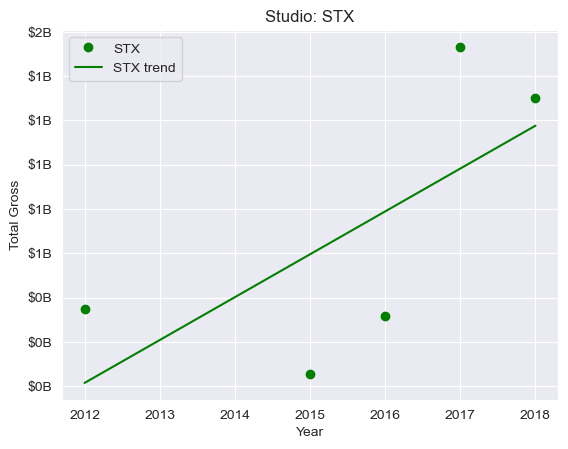


Studio: STX
 -> Slope (gross per year) = 193511320.75
 -> r2 (trend confidence) = 0.4572
 -> p-value (year coefficient) = 0.2101
 -> Trend = upward
 -> Significance = (not significant)



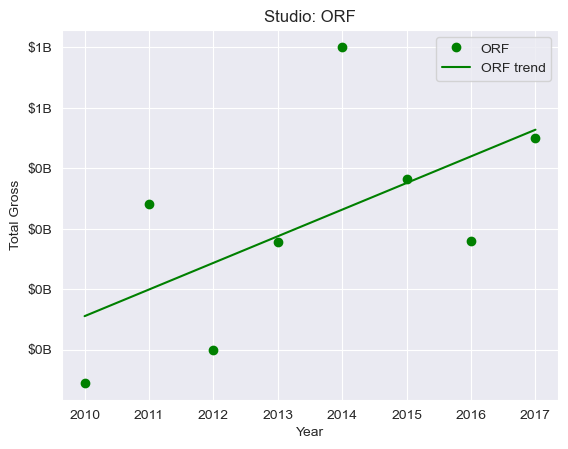


Studio: ORF
 -> Slope (gross per year) = 44046321.39
 -> r2 (trend confidence) = 0.3600
 -> p-value (year coefficient) = 0.1158
 -> Trend = upward
 -> Significance = (not significant)



In [214]:
billions = FuncFormatter(lambda x, pos: f"${x/1e9:.0f}B")

for studio_name in top_studios:
    sd = studio_year[studio_year['studio'] == studio_name]
    X = sm.add_constant(sd['year'])
    y = sd['total_gross']
    model = sm.OLS(y, X).fit()
    
    #values
    slope = model.params['year']
    r2 = model.rsquared
    p_val = model.pvalues['year']
    direction = "upward" if slope > 0 else "downward"
    significance = "significant" if p_val < 0.05 else "not significant"

    # plot only for strong trends
    if r2 > 0.3:    
        plt.plot(sd['year'], sd['total_gross'], 'o', color='green'if slope> 0 else "red", label=studio_name)
        plt.plot(sd['year'], model.predict(X), color='green'if slope> 0 else "red", label=f"{studio_name} trend")
        plt.title(f"Studio: {studio_name}")
        plt.xlabel('Year')
        plt.gca().yaxis.set_major_formatter(billions)
        plt.ylabel('Total Gross')
        plt.legend()
        plt.show()
        print(f"\nStudio: {studio_name}")
        print(f" -> Slope (gross per year) = {slope:.2f}")
        print(f" -> r2 (trend confidence) = {r2:.4f}")
        print(f" -> p-value (year coefficient) = {p_val:.4f}")
        print(f" -> Trend = {direction}") 
        print(f" -> Significance = ({significance})\n")


- R² - trend confidence - high for a competitor means they’ve built a reliably growth engine. 

- **High R²** & Low **p-value** - studios revenue trend isn’t just truly going up, it’s doing so consistently and predictably.

From the above info we can conclude that:

- **WB** and **WGSUA** has consistently high been having a growth trajectory - this should advice the marketing/branding teams to study their promotion strategy and see if they can replicate it even if on a smaller scale.


# Yearly Trend Analysis Against Other Factors

## Genres vs Year

Here we are going to take a look on how movies generes years and popularity eveolved over the years


In [215]:
#Ensure the year column is the right data type
df['year'].dtype

dtype('int64')

Since the data type is correct we can start looking at the trends

### Trend of movies released per year

This will inform us if the number of movies are increasing as time goes by or decreasing.


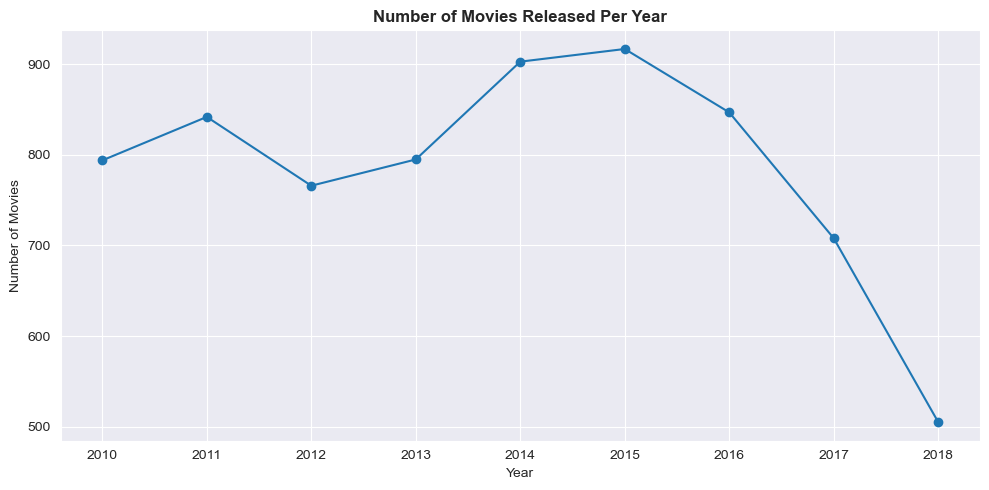

In [216]:
#group the data by year 1st
movies_per_year = df.groupby('year').size()

#plot a line grapgh to show the trend
movies_per_year.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('Number of Movies Released Per Year', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()
plt.show()

### Average Gross Over Time

THis will help how show how the market trend in terms of revenue generated by movies has changed over the years

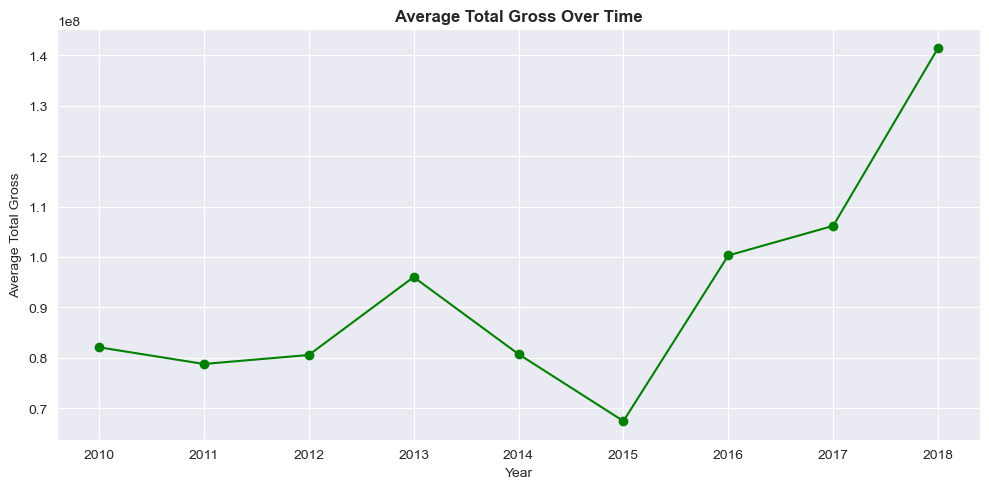

In [217]:
# Group by total gross and year then find the average gross in every year
avg_gross_by_year = df.groupby('year')['total_gross'].mean()

#plot the graph
avg_gross_by_year.plot(kind='line', figsize=(10, 5), color='green', marker='o')
plt.title('Average Total Gross Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.tight_layout()
plt.show()

- The rising trend from 2015 to 2018 suggests the film industry is growing, with movies earning more on average.

- The drop in 2015 could indicate economic challenges and a fewer blockbuster releases.

- This gives us a better understanding of movie profitability trends over time, not just how many movies were made.

- This also shows that the general trejetory in revenue generated over the years is going up indicating that this might be good investment.

In [218]:

total_gross = df.groupby('year')['total_gross'].sum().reset_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(total_gross['year'], total_gross['total_gross'])

print(f"Slope: {slope:.2f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")

Slope: 1387965933.59
R-squared: 0.247
P-value: 0.1734


- The slope is about 1.39 billion dollars per year, which means that, on average, the total earnings from all movies have been increasing by around 1.39 billion dollars annually.

- Interpretion : Significant positive slope (p < 0.05) confirms steady growth.

- The R-squared value is 0.247, meaning that only 24.7% of the change in total gross can be explained by the year.    



### Average Rating Over Time

This will help tell us whether the quality of movies have declined or improved over time


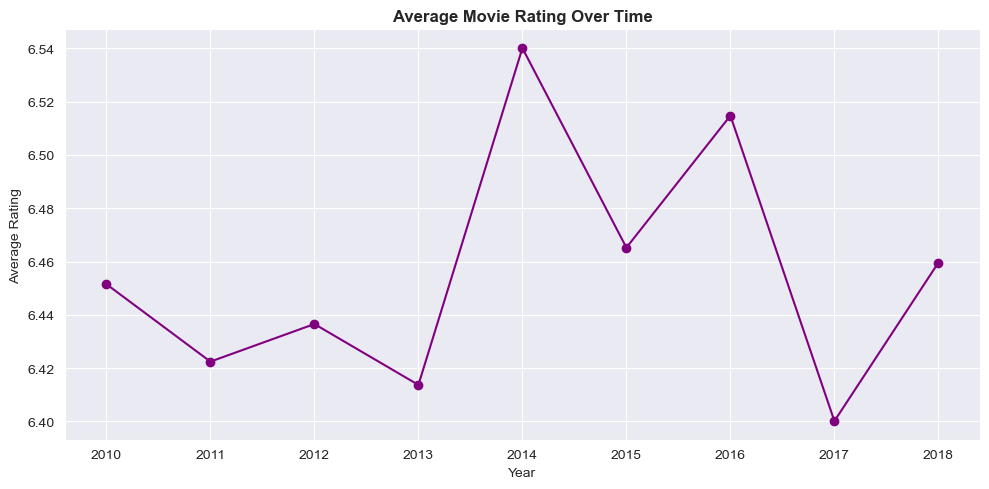

In [219]:
#group by year and ratings an find the avarage rating in each year
avg_rating_by_year = df.groupby('year')['averagerating'].mean()

#plot the graph
avg_rating_by_year.plot(kind='line', figsize=(10, 5), color='purple', marker='o')
plt.title('Average Movie Rating Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

 -  The quality of movies is all over the place and not consistent over the years explained by the audiences varying ratings

Is there a statistically significant upward trend in average ratings over time?

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df.groupby('year')['averagerating'].mean().index, df.groupby('year')['averagerating'].mean().values)

trend_direction = "upward" if slope > 0 else "downward" if slope < 0 else "neutral"
significance = "significant" if p_value < 0.05 else "not significant"

print(f"Trend: {trend_direction} ({significance})")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.3f}")

Trend: upward (not significant)
R-squared: 0.029
P-value: 0.659


 - The trend over time is slightly upward, but this trend is not statistically significant (p-value = 0.659 > 0.05) 
 - There is no strong relationship between time and performance Other factors beyond time are more important in determining performance 
 - The observed upward movement could be due to random variation

### Movie popularity over Time

This will show how movies popularity are affected by time

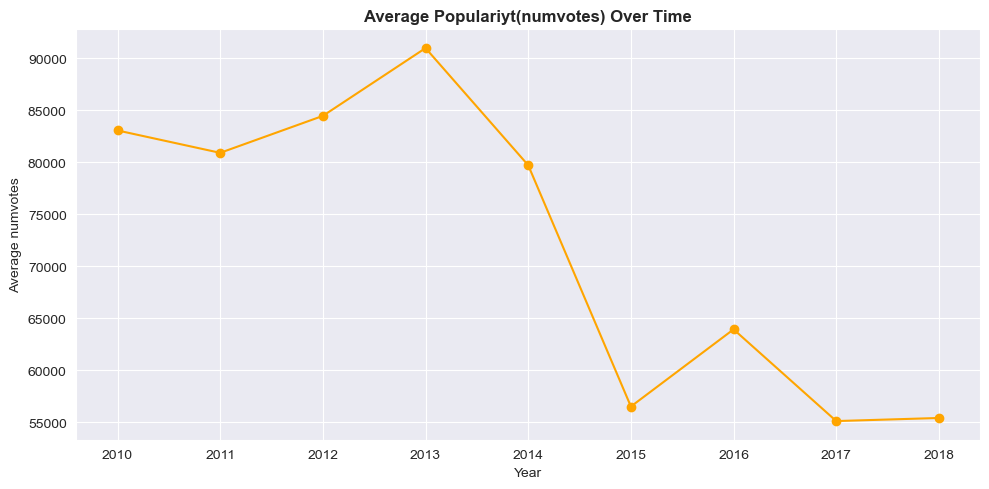

In [221]:
#group by year and find the avarage number of votesin each year
avg_pop_by_yr = df.groupby('year')['numvotes'].mean()

#plot the popularity graph
avg_pop_by_yr.plot(kind='line', figsize=(10, 5), color='orange', marker='o')
plt.title('Average Populariyt(numvotes) Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average numvotes')
plt.grid(True)
plt.tight_layout()
plt.show()

 - Marketing in the industry has gone down over the years and this is a good opportunity for us to take advantage of this and market our movies to the audience

### Genre trends over Time

Here we will be looking at how trends in genre has evolved over time

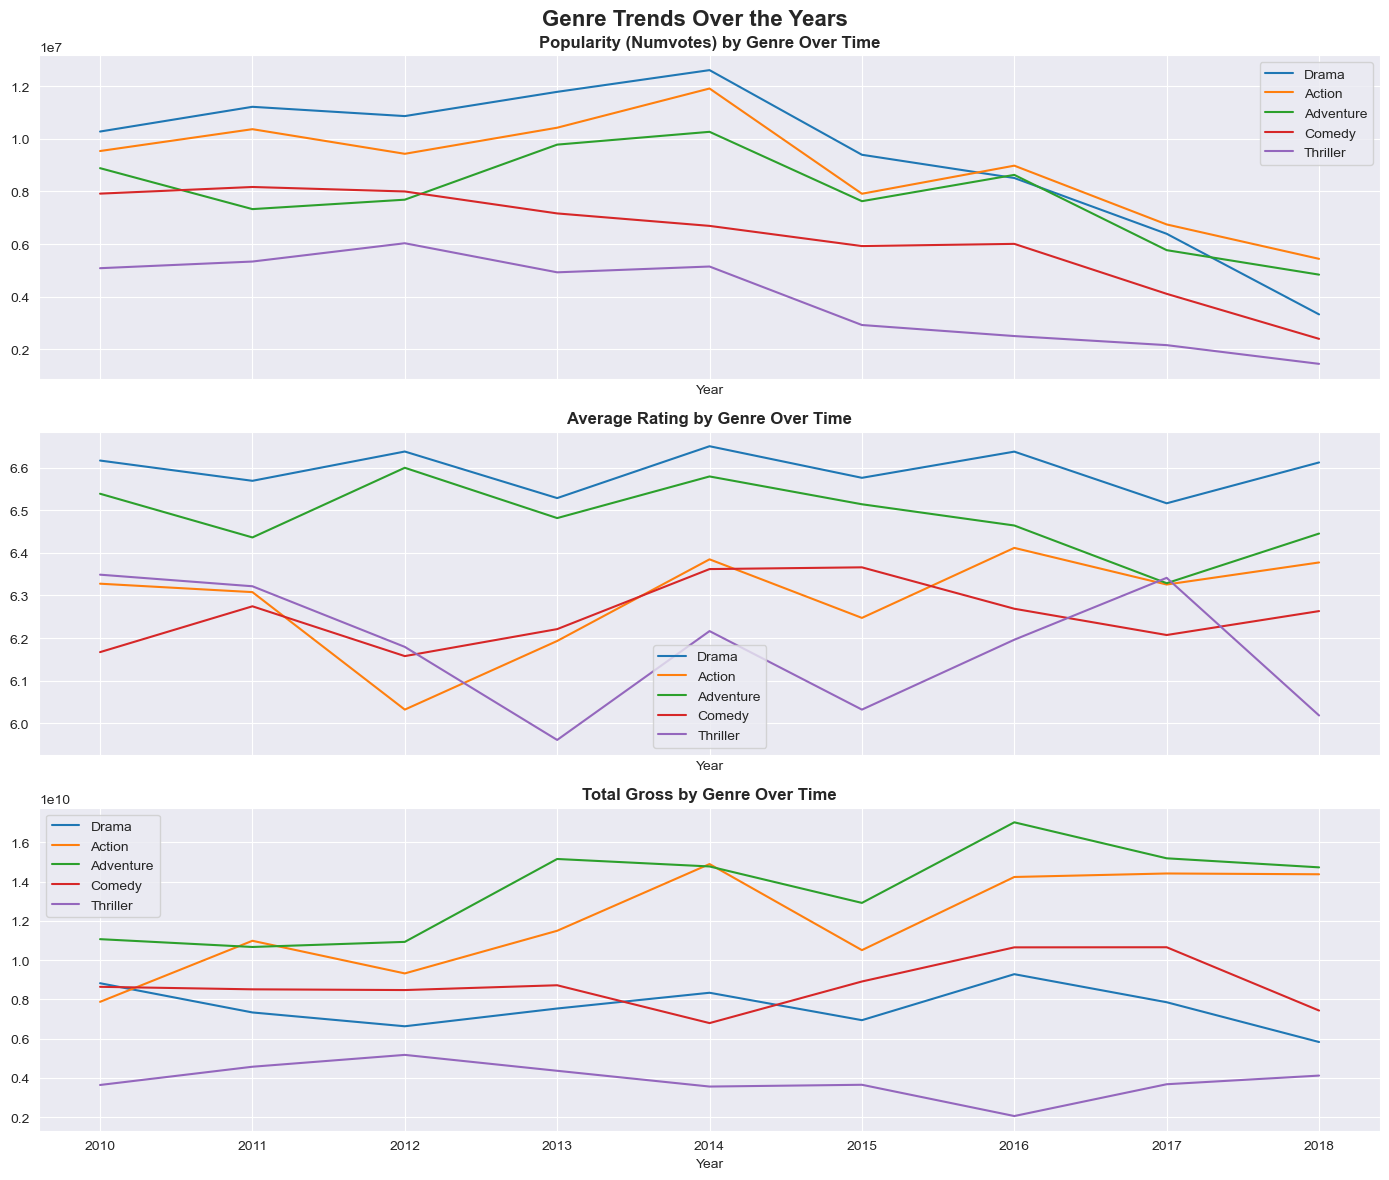

In [222]:
# Group by year and genre
grouped = df.groupby(['year', 'genres'])

# Sum of numvotes (popularity) instead of count of movies
popularity_by_genre = grouped['numvotes'].sum().unstack(fill_value=0)
avg_rating_by_genre = grouped['averagerating'].mean().unstack(fill_value=0)
total_gross_by_genre = grouped['total_gross'].sum().unstack(fill_value=0)

# Top 5 genres by popularity
top_genres = popularity_by_genre.sum().sort_values(ascending=False).head().index

# Create a figure for our subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Popularity (numvotes) by genre
for genre in top_genres:
    axs[0].plot(popularity_by_genre.index, popularity_by_genre[genre], label=genre)
axs[0].set_title("Popularity (Numvotes) by Genre Over Time", weight='bold')
axs[0].set_xlabel("Year")
axs[0].legend()
axs[0].grid(True)

# Average rating by genre
for genre in top_genres:
    axs[1].plot(avg_rating_by_genre.index, avg_rating_by_genre[genre], label=genre)
axs[1].set_title("Average Rating by Genre Over Time", weight='bold')
axs[1].set_xlabel("Year")
axs[1].legend()
axs[1].grid(True)

# Total gross by genre
for genre in top_genres:
    axs[2].plot(total_gross_by_genre.index, total_gross_by_genre[genre], label=genre)
axs[2].set_title("Total Gross by Genre Over Time", weight='bold')
axs[2].set_xlabel("Year")
axs[2].legend()
axs[2].grid(True)

plt.suptitle('Genre Trends Over the Years', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Overall Insight

These combined trends help us understand not just which genres are popular, but also how they're perceived and how financially successful they are. This can guide decisions in movie production, marketing, or investment.

# Final Conclusions

Based on our holistic statistical analysis of the data and the film industry, we can draw several key conclusions:

- **High R²** & Low **p-value** - studios revenue trend isn’t just truly going up, it’s doing so consistently and predictably.

- **WB** and **WGSUA** has consistently high been having a growth trajectory - this should advice the marketing/branding teams to study their promotion strategy and see if they can replicate it even if on a smaller scale.

- popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated

- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot

- As popularity being a factor to making money then yes because the most popular genre is the most profitable

- **Shorter films (<60 minutes)** tend to receive marginally higher ratings - with a weak positive correlation of 0.15 between runtime and rating **(p-value < 0.001)**

- There is a statistically significant correlation between runtime size and ratings but the small coefficient suggests runtime has limited practical impact on ratings

 - In as much as shorter films are rated higher, the difference is not substantial enough to warrant a focus on runtime. Instead, we should focus really significant factors
